# Predicting Returning Customers with GA4 Behavioral Data

This notebook builds a machine learning model to predict whether users active in November-December 2020 returned in January 2021. The analysis uses GA4 ecommerce behavioral, recency, traffic source, device, and geography features to score users for potential re-engagement.

In [97]:
# load libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.cloud import bigquery

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score,
)

In [98]:
# load data from BigQuery

PROJECT_ID = "ga4-ecommerce-portfolio-504020"
client = bigquery.Client(project=PROJECT_ID)
query = """
SELECT *
FROM `ga4-ecommerce-portfolio-504020.ga4_ecommerce.mart_customer_features`
"""
df = client.query(query).to_dataframe()
df.shape

/Users/nikkifackler/Library/CloudStorage/OneDrive-UniversityofNorthCarolinaatChapelHill/Fackler/Git Repos/GA4-Ecommerce-Funnel-Analytics-ML/.venv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


(179085, 37)

In [99]:
# inspect data 

df.head()
df.info()   
df["came_back_in_january"].value_counts()
df["came_back_in_january"].value_counts(normalize=True)

<class 'pandas.DataFrame'>
RangeIndex: 179085 entries, 0 to 179084
Data columns (total 37 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   user_pseudo_id                   179085 non-null  str    
 1   first_seen_date                  179085 non-null  dbdate 
 2   last_seen_date                   179085 non-null  dbdate 
 3   days_since_last_seen             179085 non-null  Int64  
 4   customer_span_days               179085 non-null  Int64  
 5   active_days_last_7_days          179085 non-null  Int64  
 6   active_days_last_14_days         179085 non-null  Int64  
 7   events_last_7_days               179085 non-null  Int64  
 8   events_last_14_days              179085 non-null  Int64  
 9   active_days                      179085 non-null  Int64  
 10  total_events                     179085 non-null  Int64  
 11  view_item_events                 179085 non-null  Int64  
 12  add_to_cart_e

came_back_in_january
0    0.979222
1    0.020778
Name: proportion, dtype: Float64

In [100]:
# inspect missing values

df.isna().sum().sort_values(ascending=False)

user_pseudo_id                     0
last_device_category               0
last_traffic_medium                0
session_count                      0
avg_session_duration_seconds       0
max_session_duration_seconds       0
purchase_sessions                  0
ordered_view_item_sessions         0
ordered_add_to_cart_sessions       0
ordered_begin_checkout_sessions    0
ordered_add_shipping_sessions      0
ordered_add_payment_sessions       0
ordered_purchase_sessions          0
avg_events_per_session             0
purchases_per_session              0
revenue_per_session                0
came_back_in_january               0
last_traffic_source                0
last_country                       0
first_seen_date                    0
total_revenue                      0
last_seen_date                     0
days_since_last_seen               0
customer_span_days                 0
active_days_last_7_days            0
active_days_last_14_days           0
events_last_7_days                 0
e

In [101]:
# descriptive statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
days_since_last_seen,179085.0,28.162632,16.704506,0.0,15.0,26.0,42.0,60.0
customer_span_days,179085.0,1.055404,4.747729,0.0,0.0,0.0,0.0,60.0
active_days_last_7_days,179085.0,0.106212,0.32778,0.0,0.0,0.0,0.0,6.0
active_days_last_14_days,179085.0,0.235866,0.474595,0.0,0.0,0.0,0.0,9.0
events_last_7_days,179085.0,1.044878,7.489626,0.0,0.0,0.0,0.0,586.0
events_last_14_days,179085.0,2.594288,13.283563,0.0,0.0,0.0,0.0,730.0
active_days,179085.0,1.186593,0.646554,1.0,1.0,1.0,1.0,12.0
total_events,179085.0,17.228897,42.601763,1.0,4.0,5.0,12.0,1309.0
view_item_events,179085.0,1.67014,7.1146,0.0,0.0,0.0,0.0,330.0
add_to_cart_events,179085.0,0.240227,1.919879,0.0,0.0,0.0,0.0,98.0


In [102]:
# separate numeric and categorical columns

numeric_cols = df.select_dtypes(include=["number", "Int64", "float64", "int64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

numeric_cols = [col for col in numeric_cols if col not in ["came_back_in_january", "purchased_in_january"]]
categorical_cols = [col for col in categorical_cols if col != "user_pseudo_id"]

len(numeric_cols), len(categorical_cols)

(28, 4)

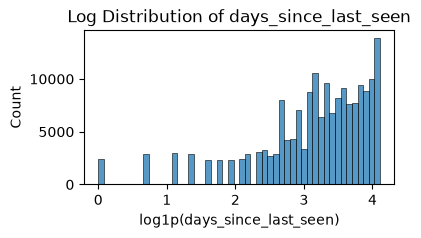

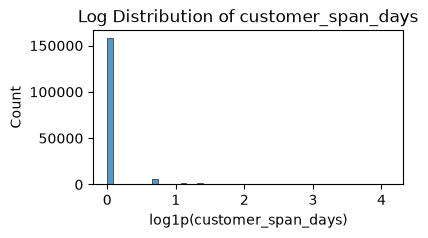

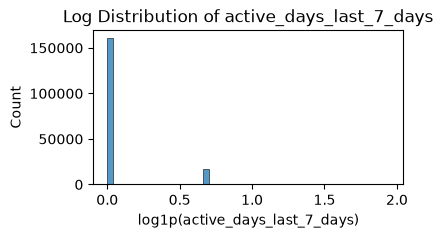

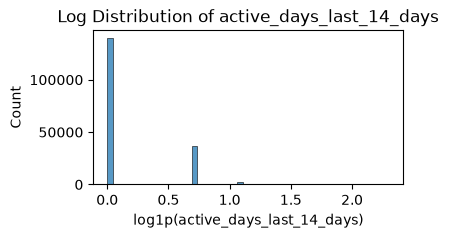

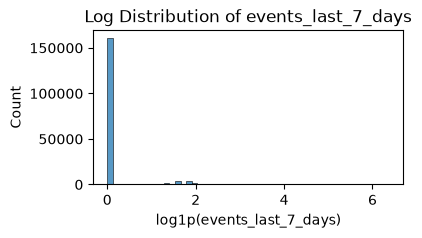

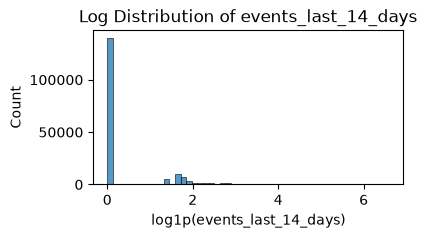

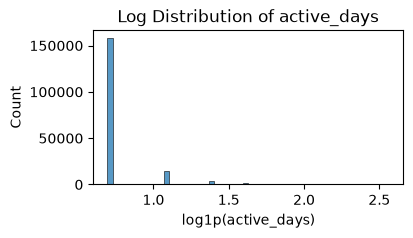

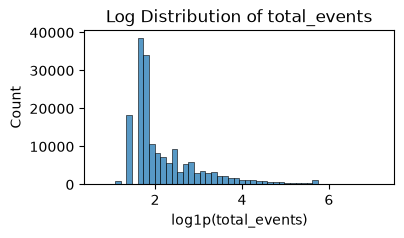

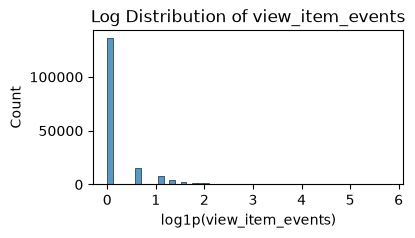

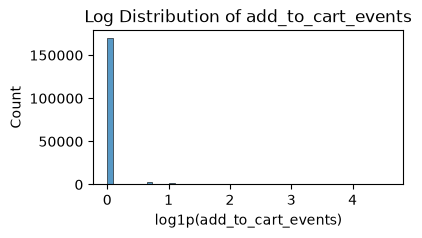

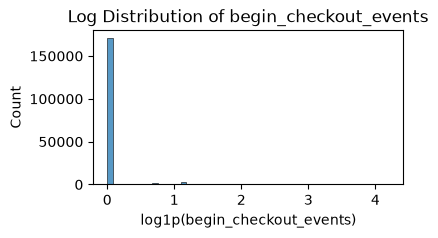

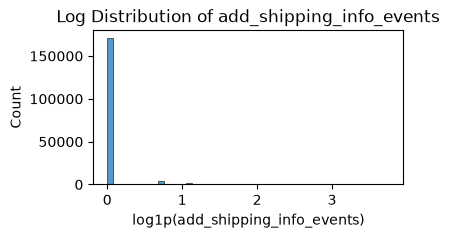

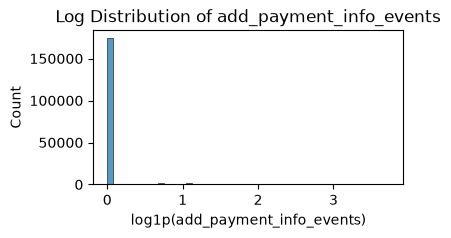

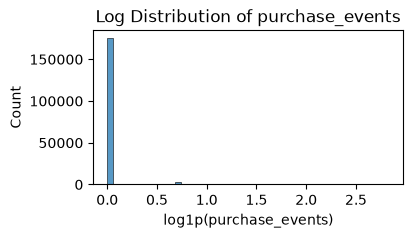

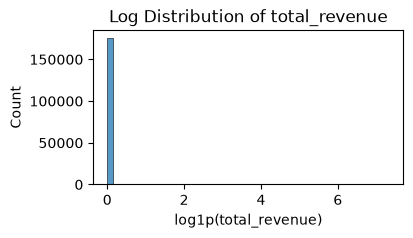

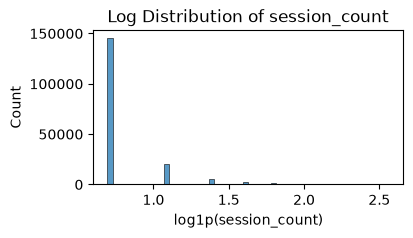

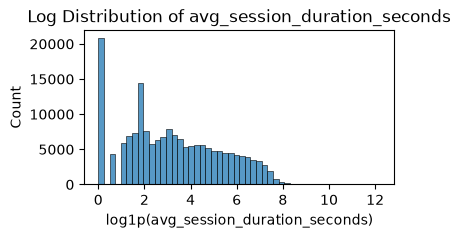

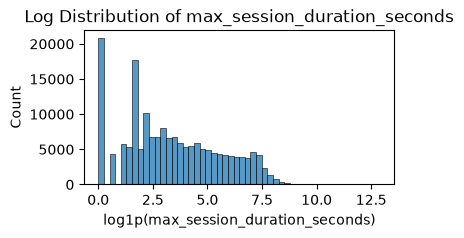

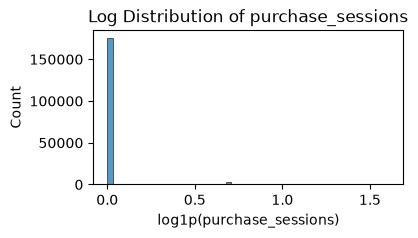

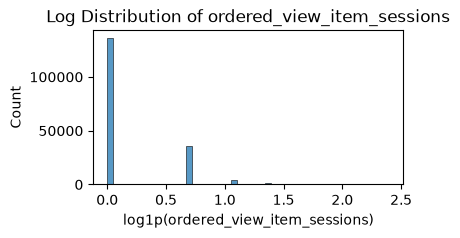

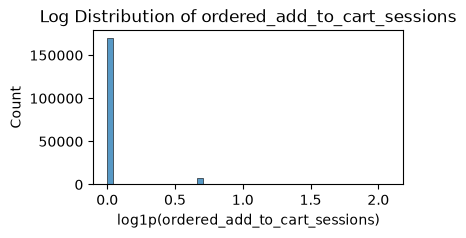

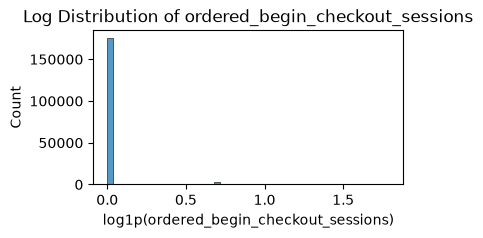

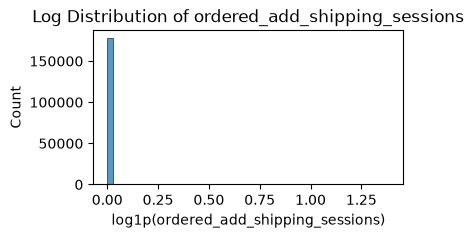

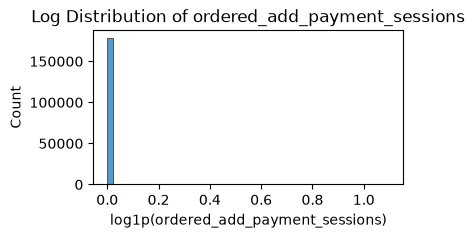

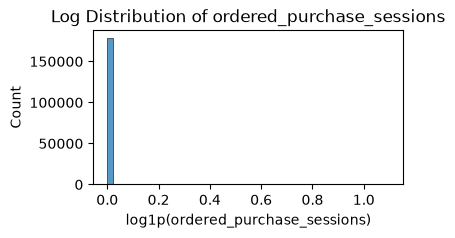

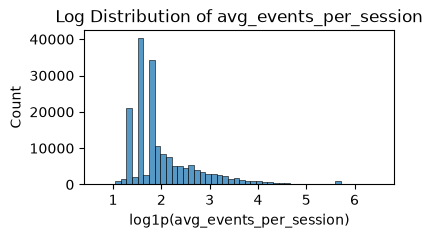

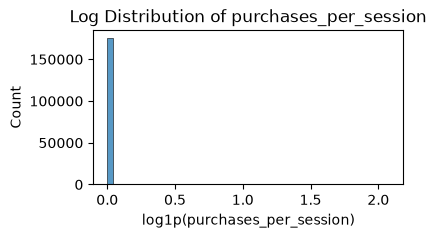

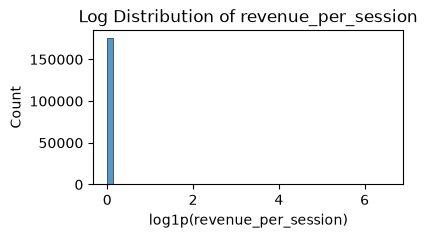

In [103]:
# visualize distributions of numeric columns

for col in numeric_cols:
    plt.figure(figsize=(4, 2))
    sns.histplot(np.log1p(df[col]), bins=50)
    plt.title(f"Log Distribution of {col}")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Count")
    plt.show()

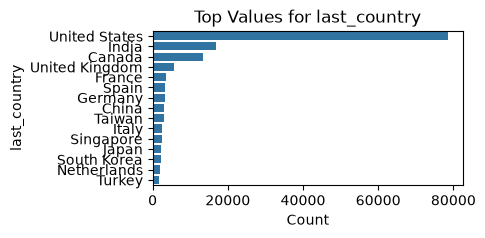

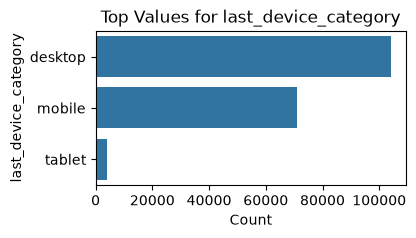

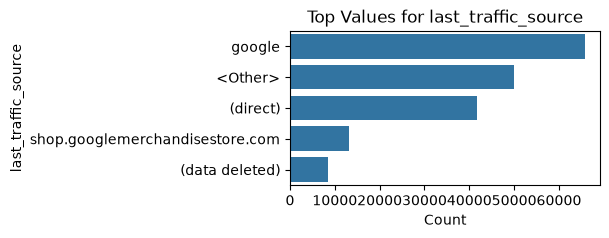

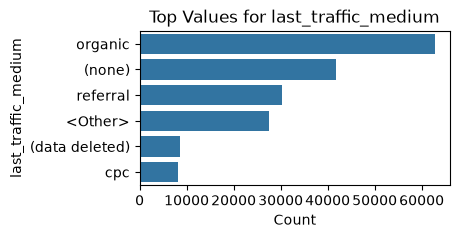

In [104]:
# visualize distributions of categorical columns

for col in categorical_cols:
    plt.figure(figsize=(4, 2))
    top_values = df[col].value_counts().head(15)

    sns.barplot(
        x=top_values.values,
        y=top_values.index
    )

    plt.title(f"Top Values for {col}")
    plt.xlabel("Count")
    plt.ylabel(col)
    plt.show()

Feature distributions show strong right skew and sparsity (typical of ecommerce data). Most users have only one active day or session during the observation window, while a smaller group has higher engagement. Recency features are also sparse. 

In [105]:
# define target variable and feature sets

target = "came_back_in_january"
exclude_cols = [
    "user_pseudo_id",
    "first_seen_date",
    "last_seen_date",
    "came_back_in_january",
    "purchased_in_january"
    ]
feature_cols = [col for col in df.columns if col not in exclude_cols]
X = df[feature_cols]
y = df[target].astype(int)

categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_features = X.select_dtypes(include=["number", "Int64", "float64", "int64"]).columns.tolist()

X.shape, y.shape, len(numeric_features), len(categorical_features)

((179085, 32), (179085,), 28, 4)

In [106]:
# train-test split (stratified)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=33,
    stratify=y
)
y_train.mean(), y_test.mean()

(np.float64(0.02077923890889801), np.float64(0.02077225898316442))

The target is highly imbalanced, with returning users making up about 2.1% of both the training and test sets. Stratifying the split preserves the same class balance in both samples.

In [107]:
# establish baseline model (predicting all zeros)

baseline_pred = np.zeros_like(y_test)
print(classification_report(y_test, baseline_pred, zero_division=0))
confusion_matrix(y_test, baseline_pred)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     35073
           1       0.00      0.00      0.00       744

    accuracy                           0.98     35817
   macro avg       0.49      0.50      0.49     35817
weighted avg       0.96      0.98      0.97     35817



array([[35073,     0],
       [  744,     0]])

In [108]:
# build logistic regression model with preprocessing for numeric and categorical features

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)
log_reg = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000)),
    ]
)
log_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['days_since_last_seen','customer_span_days','active_days_last_7_days',..., 'avg_events_per_session','purchases_per_session','revenue_per_session']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolu

In [109]:
# evaluate logistic regression model

log_reg_pred = log_reg.predict(X_test)
log_reg_proba = log_reg.predict_proba(X_test)[:, 1]
print(classification_report(y_test, log_reg_pred, zero_division=0))
confusion_matrix(y_test, log_reg_pred)

              precision    recall  f1-score   support

           0       0.99      0.79      0.88     35073
           1       0.06      0.67      0.12       744

    accuracy                           0.79     35817
   macro avg       0.53      0.73      0.50     35817
weighted avg       0.97      0.79      0.86     35817



array([[27767,  7306],
       [  246,   498]])

In [110]:
# evaluate model performance using ROC AUC and PR AUC 

print("ROC AUC:", roc_auc_score(y_test, log_reg_proba))
print("PR AUC:", average_precision_score(y_test, log_reg_proba))

ROC AUC: 0.7988657451478316
PR AUC: 0.13870158530408191


The model achieves moderate recall for the returning-user class, correctly identifying 67% of users who actually came back in January. However, precision is low at 6%, meaning most users predicted as returners did not actually return.

The ROC AUC of 0.80 suggests the model has meaningful ability to separate returning users from non-returning users. Because the positive class is rare, PR AUC is especially important; the PR AUC of 0.14 is well above the baseline return rate of about 0.02, indicating that the model ranks returning users better than random selection.

Overall, this model is more appropriate for broad re-engagement audience scoring than for high-confidence individual prediction.

In [111]:
# build random forest model

rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=33,
                n_jobs=-1,
            ),
        ),
    ]
)

rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['days_since_last_seen','customer_span_days','active_days_last_7_days',..., 'avg_events_per_session','purchases_per_session','revenue_per_session']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolu

In [112]:
# evaluate random forest model

rf_pred = rf.predict(X_test)
rf_proba = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, rf_pred, zero_division=0))
print(confusion_matrix(y_test, rf_pred))
print("ROC AUC:", roc_auc_score(y_test, rf_proba))
print("PR AUC:", average_precision_score(y_test, rf_proba))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98     35073
           1       0.14      0.09      0.11       744

    accuracy                           0.97     35817
   macro avg       0.56      0.54      0.55     35817
weighted avg       0.96      0.97      0.97     35817

[[34674   399]
 [  680    64]]
ROC AUC: 0.7833030048847428
PR AUC: 0.08980793764610287


The random forest model is more conservative than logistic regression at the default threshold. It produces fewer positive predictions and achieves higher precision at 14%, but recall falls to 9%, meaning it misses most returning users.

Its ROC AUC is similar to logistic regression, but its PR AUC is lower. Because this is a rare-class problem, the lower PR AUC suggests that random forest is less effective at ranking likely returners in this setup.

In [113]:
# build gradient boosting model

gb = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=200,
                class_weight="balanced",
                random_state=33,
            ),
        ),
    ]
)
gb.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['days_since_last_seen','customer_span_days','active_days_last_7_days',..., 'avg_events_per_session','purchases_per_session','revenue_per_session']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolu

In [114]:
# evaluate gradient boosting model

gb_pred = gb.predict(X_test)
gb_proba = gb.predict_proba(X_test)[:, 1]

print(classification_report(y_test, gb_pred, zero_division=0))
print(confusion_matrix(y_test, gb_pred))
print("ROC AUC:", roc_auc_score(y_test, gb_proba))
print("PR AUC:", average_precision_score(y_test, gb_proba))


              precision    recall  f1-score   support

           0       0.99      0.81      0.89     35073
           1       0.07      0.68      0.13       744

    accuracy                           0.81     35817
   macro avg       0.53      0.75      0.51     35817
weighted avg       0.97      0.81      0.88     35817

[[28385  6688]
 [  235   509]]
ROC AUC: 0.8305512710969349
PR AUC: 0.17271010190447925


Gradient boosting produced the strongest overall ranking performance among the models tested. It identified 68% of returning users, while precision remained low at 7%. It achieved the highest ROC AUC and PR AUC. Because the positive class is rare, the PR AUC of 0.17 is especially important: it is substantially higher than the baseline return rate of about 0.021.

However, precision remains low at the default threshold, so the model should still be interpreted as an audience-scoring tool rather than a high-confidence individual prediction model.

In [115]:
# cross-validation for gradient boosting model with .5 threshold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=33
)
cv_results = cross_validate(
    gb,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision",
        "f1": "f1",
    },
    n_jobs=-1
)
pd.DataFrame(cv_results).agg(["mean", "std"]).T

,mean,std
fit_time,15.395514,1.886629
score_time,0.648527,0.084489
test_roc_auc,0.828510,0.008971
test_pr_auc,0.171064,0.008074
test_f1,0.134307,0.002432


Cross-validation was used to evaluate whether the gradient boosting model's performance was stable across different training folds. The model achieved an average ROC AUC of 0.83 with very low variation across folds, suggesting stable ranking performance.

The average PR AUC was 0.17 with low variation across folds, which is substantially higher than the baseline return rate of about 2.1%. The model consistently identifies signal beyond random selection.

The cross-validated F1 score is based on the default 0.5 threshold, so it should be interpreted separately from the later threshold-tuning results.

In [116]:
# generate out-of-fold predicted probabilities on training data for threshold tuning

gb_cv_proba = cross_val_predict(
    gb,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [117]:
# threshold tuning for gradient boosting model using out-of-fold training probabilities

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

threshold_results = []

for threshold in thresholds:
    preds = (gb_cv_proba >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_train, preds, zero_division=0),
        "recall": recall_score(y_train, preds, zero_division=0),
        "f1": f1_score(y_train, preds, zero_division=0),
        "predicted_positives": preds.sum()
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,precision,recall,f1,predicted_positives
0,0.1,0.021878,0.993282,0.042814,135156
1,0.2,0.031361,0.920054,0.060654,87338
2,0.3,0.044575,0.852536,0.084720,56938
3,0.4,0.057606,0.774269,0.107234,40013
4,0.5,0.074235,0.705072,0.134327,28275
5,0.6,0.094031,0.614377,0.163100,19451
6,0.7,0.122772,0.513604,0.198173,12454
7,0.8,0.178223,0.361774,0.238803,6043
8,0.9,0.312867,0.160900,0.212511,1531


Threshold tuning using out-of-fold training predictions shows a clear precision-recall tradeoff. At low thresholds, the model captures most returning users but selects a very large audience with low precision. At higher thresholds, the model produces a smaller, more targeted audience with higher precision.

A threshold around 0.8 provides the strongest F1 score of 0.24, identifying 36% of returning users while improving precision to 18%.

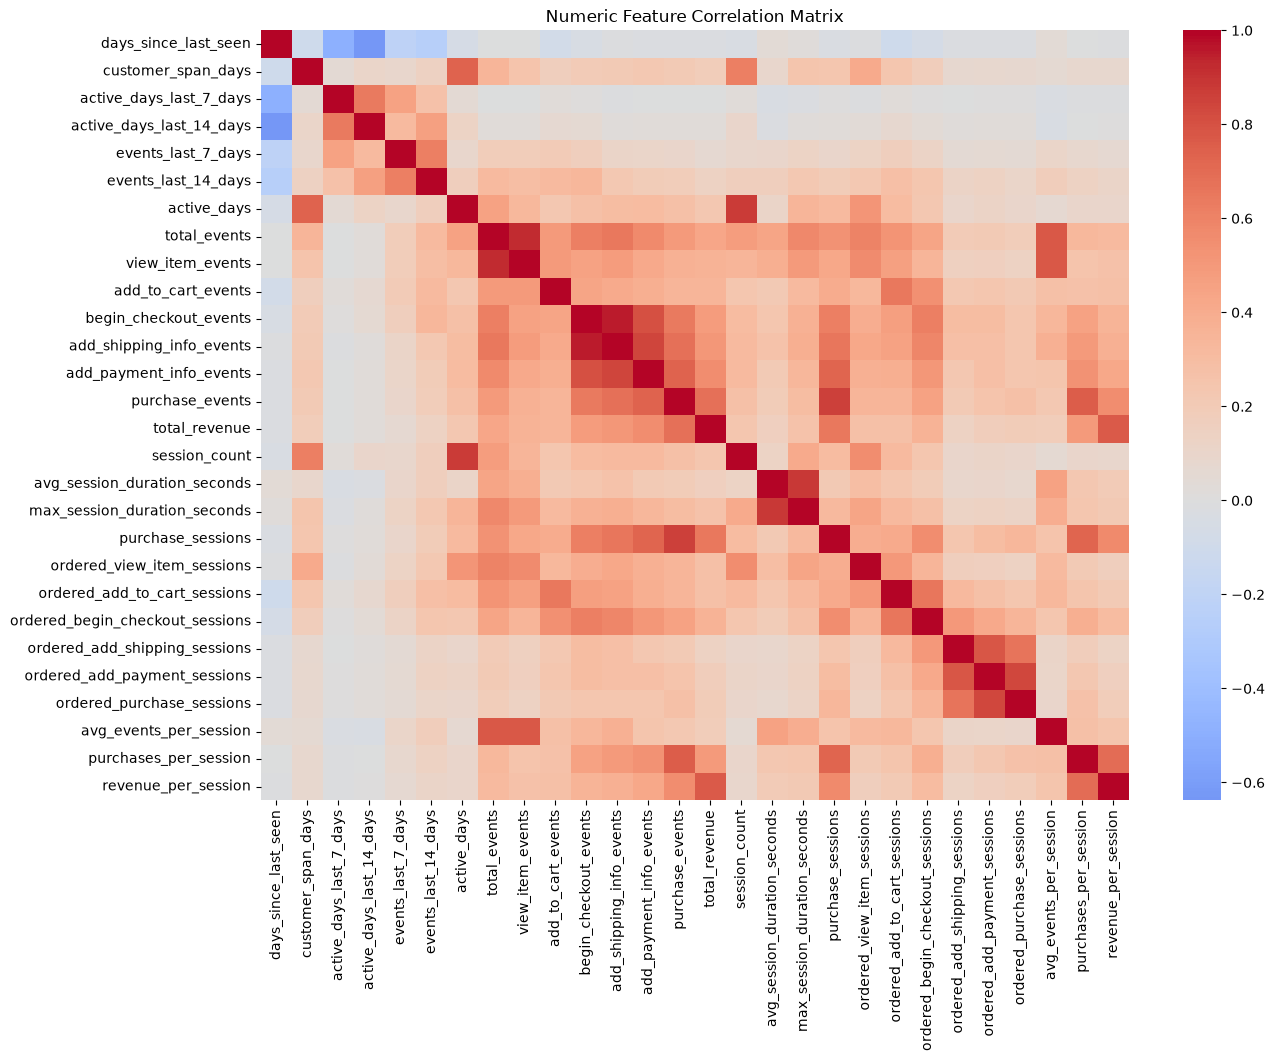

In [118]:
# correlation matrix for numeric features

corr = X_train[numeric_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation Matrix")
plt.show()

In [119]:
# identify highly correlated feature pairs 

corr_pairs = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)

corr_pairs.head(25)

begin_checkout_events          add_shipping_info_events           0.950716
total_events                   view_item_events                   0.924394
avg_session_duration_seconds   max_session_duration_seconds       0.880713
active_days                    session_count                      0.873277
purchase_events                purchase_sessions                  0.865059
add_shipping_info_events       add_payment_info_events            0.844380
ordered_add_payment_sessions   ordered_purchase_sessions          0.837164
begin_checkout_events          add_payment_info_events            0.804375
ordered_add_shipping_sessions  ordered_add_payment_sessions       0.788162
view_item_events               avg_events_per_session             0.774428
total_events                   avg_events_per_session             0.771303
total_revenue                  revenue_per_session                0.768440
purchase_events                purchases_per_session              0.761702
add_payment_info_events  

The correlation analysis shows substantial overlap among several numeric behavior features. Funnel-step counts are strongly correlated with one another, session-duration features are highly correlated, and purchase/revenue fields carry similar information. This is expected in ecommerce clickstream data because users with more activity tend to generate more sessions, more product views, and more downstream funnel events.

To reduce redundancy, the reduced model retains a smaller set of representative features spanning recency, overall engagement, session behavior, funnel progression, and prior purchasing activity. This allows us to test whether most of the predictive signal can be preserved with a simpler feature set.

In [120]:
# reduce features based on correlation

reduced_numeric_features = [
    "days_since_last_seen",
    "customer_span_days",
    "events_last_14_days",
    "total_events",
    "session_count",
    "max_session_duration_seconds",
    "begin_checkout_events",
    "purchase_events",
    "total_revenue",
]
reduced_categorical_features = categorical_features
reduced_feature_cols = reduced_numeric_features + reduced_categorical_features


In [121]:
# train reduced gradient boosting model

X_train_reduced = X_train[reduced_feature_cols]
X_test_reduced = X_test[reduced_feature_cols]
reduced_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), reduced_numeric_features),
        ("categorical", OneHotEncoder(handle_unknown="ignore", sparse_output=False), reduced_categorical_features),
    ]
)
gb_reduced = Pipeline(
    steps=[
        ("preprocessor", reduced_preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=200,
                class_weight="balanced",
                random_state=33,
            ),
        ),
    ]
)
gb_reduced.fit(X_train_reduced, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['days_since_last_seen','customer_span_days','events_last_14_days',..., 'last_device_category','last_traffic_source','last_traffic_medium']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are 

In [122]:
# evaluate reduced gradient boosting model

gb_reduced_pred = gb_reduced.predict(X_test_reduced)
gb_reduced_proba = gb_reduced.predict_proba(X_test_reduced)[:, 1]

print(classification_report(y_test, gb_reduced_pred, zero_division=0))
print(confusion_matrix(y_test, gb_reduced_pred))
print("ROC AUC:", roc_auc_score(y_test, gb_reduced_proba))
print("PR AUC:", average_precision_score(y_test, gb_reduced_proba))

              precision    recall  f1-score   support

           0       0.99      0.81      0.89     35073
           1       0.07      0.69      0.13       744

    accuracy                           0.81     35817
   macro avg       0.53      0.75      0.51     35817
weighted avg       0.97      0.81      0.88     35817

[[28422  6651]
 [  232   512]]
ROC AUC: 0.8300878559281425
PR AUC: 0.16962924761883186


The reduced gradient boosting model performs nearly identically to the full model. ROC AUC remains around 0.83 and PR AUC remains around 0.17, indicating that most predictive signal is captured by a smaller set of recency, engagement, session-quality, funnel, purchase, and categorical features.

This suggests that many of the removed variables were redundant with the retained features. The reduced model is easier to interpret while preserving essentially the same ranking performance.

In [123]:
# cross-validation for reduced gradient boosting model with .5 threshold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=33
)
cv_results_reduced = cross_validate(
    gb_reduced,
    X_train_reduced,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision",
        "f1": "f1",
    },
    n_jobs=-1
)
pd.DataFrame(cv_results_reduced).agg(["mean", "std"]).T

,mean,std
fit_time,10.895067,1.190101
score_time,0.497111,0.061933
test_roc_auc,0.827001,0.008612
test_pr_auc,0.165887,0.010496
test_f1,0.131864,0.003844


In [124]:
# generate out-of-fold predicted probabilities on training data for threshold tuning

gb_reduced_cv_proba = cross_val_predict(
    gb_reduced,
    X_train_reduced,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

In [125]:
# threshold tuning for reduced gradient boosting model

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

threshold_results = []

for threshold in thresholds:
    preds = (gb_reduced_cv_proba >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_train, preds, zero_division=0),
        "recall": recall_score(y_train, preds, zero_division=0),
        "f1": f1_score(y_train, preds, zero_division=0),
        "predicted_positives": preds.sum()
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,precision,recall,f1,predicted_positives
0,0.1,0.021553,0.996641,0.042194,137659
1,0.2,0.030435,0.925428,0.058932,90520
2,0.3,0.043841,0.856231,0.083411,58142
3,0.4,0.056733,0.778636,0.105760,40858
4,0.5,0.072786,0.700034,0.131861,28632
5,0.6,0.093450,0.618744,0.162377,19711
6,0.7,0.121193,0.515956,0.196281,12674
7,0.8,0.177314,0.365469,0.238780,6136
8,0.9,0.317770,0.153174,0.206709,1435


Among the tested thresholds, 0.8 provides the strongest F1 score for the reduced model. At this threshold, the model identifies 37% of returning users with 18% precision. This is a more practical operating point than the default 0.5 threshold because it creates a smaller and more targeted audience.

A threshold of 0.9 produces higher precision at 32%, but recall falls to 15%, so it may be preferable only if the goal is a much smaller, higher-confidence audience.

In [126]:
# evaluate reduced gradient boosting model with selected threshold

selected_threshold = 0.8

gb_reduced_test_pred_08 = (gb_reduced_proba >= selected_threshold).astype(int)

print(classification_report(y_test, gb_reduced_test_pred_08, zero_division=0))
print(confusion_matrix(y_test, gb_reduced_test_pred_08))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97     35073
           1       0.18      0.41      0.25       744

    accuracy                           0.95     35817
   macro avg       0.58      0.68      0.61     35817
weighted avg       0.97      0.95      0.96     35817

[[33717  1356]
 [  441   303]]


A threshold of 0.8 identified 41% of returning users with 18% precision and selected 1,659 users as likely returners.

In [127]:
# feature importance for reduced gradient boosting model

perm_importance = permutation_importance(
    gb_reduced,
    X_test_reduced,
    y_test,
    scoring="average_precision",
    n_repeats=5,
    random_state=33,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test_reduced.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std,
}).sort_values("importance_mean", ascending=False)

importance_df.head(15)


,feature,importance_mean,importance_std
0,days_since_last_seen,0.094329,0.005420
1,customer_span_days,0.051240,0.003353
3,total_events,0.039601,0.001711
4,session_count,0.009655,0.002828
5,max_session_duration_seconds,0.006045,0.002481
2,events_last_14_days,0.002126,0.000392
11,last_traffic_source,0.001395,0.000496
8,total_revenue,0.001123,0.000034
10,last_device_category,0.000789,0.000368
7,purchase_events,-0.000063,0.000170


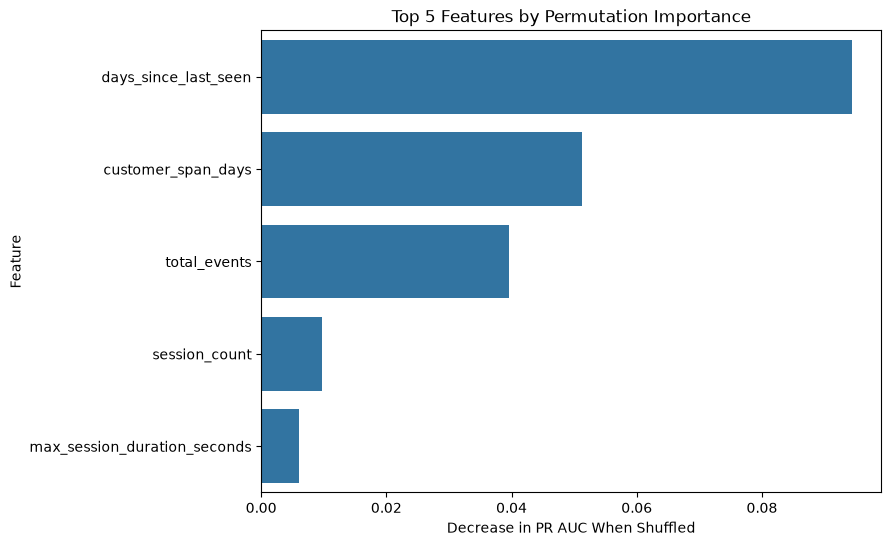

In [128]:
# visualize top five features by permutation importance

top_importance = importance_df.head(5)

plt.figure(figsize=(8, 6))
sns.barplot(
    data=top_importance,
    x="importance_mean",
    y="feature"
)

plt.title("Top 5 Features by Permutation Importance")
plt.xlabel("Decrease in PR AUC When Shuffled")
plt.ylabel("Feature")

plt.savefig("../figures/permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()

Permutation importance measures how much model performance decreases when each feature is randomly shuffled. Features with larger decreases are more important because disrupting them harms the model's ability to rank likely returning users.

The most important features are recency and engagement measures, especially `days_since_last_seen`, `customer_span_days`, and `total_events`. This suggests that users who were active more recently and showed stronger engagement during the observation window were more likely to return in January.

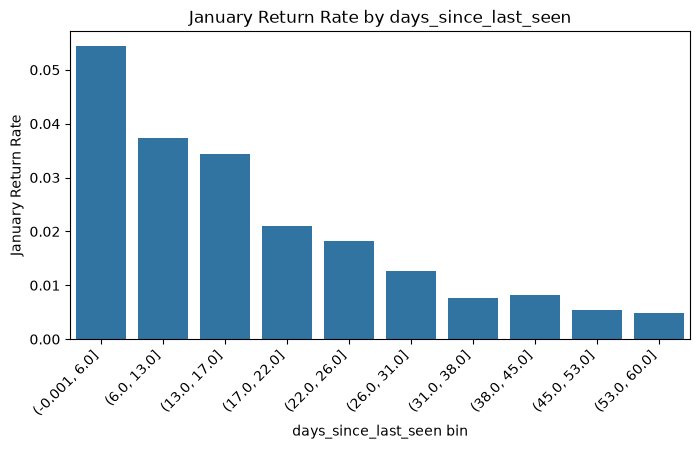

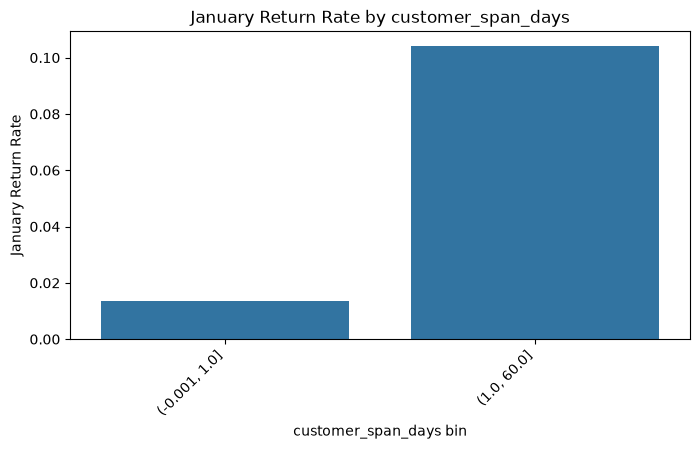

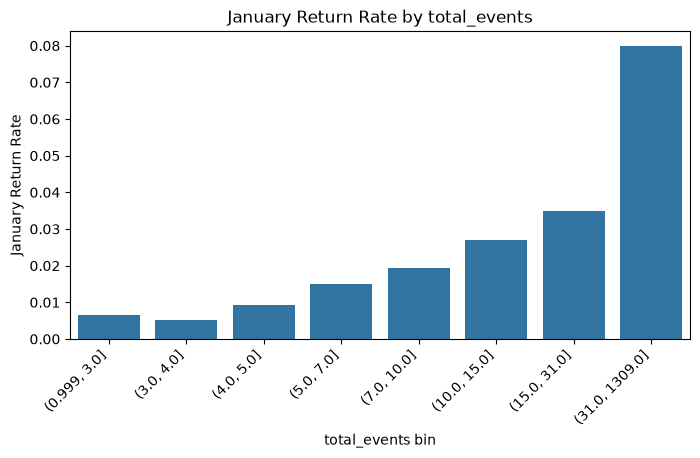

In [129]:
top_features = [
    "days_since_last_seen",
    "customer_span_days",
    "total_events",
]

for feature in top_features:
    feature_bins = pd.qcut(
        df[feature],
        q=10,
        duplicates="drop"
    )

    feature_return_rate = (
        df.groupby(feature_bins, observed=True)["came_back_in_january"]
        .mean()
        .reset_index(name="return_rate")
    )

    plt.figure(figsize=(8, 4))
    sns.barplot(
        data=feature_return_rate,
        x=feature,
        y="return_rate"
    )

    plt.xticks(rotation=45, ha="right")
    plt.title(f"January Return Rate by {feature}")
    plt.xlabel(f"{feature} bin")
    plt.ylabel("January Return Rate")
    plt.show()

## Conclusions

This analysis built a binary classification model to predict whether users active in November-December 2020 returned in January 2021. Because only about 2.1% of users returned, this is a highly imbalanced classification problem, so PR AUC, recall, precision, and threshold tradeoffs are more informative than accuracy alone.

Gradient boosting performed best among the models tested. The full gradient boosting model achieved ROC AUC of 0.83 and PR AUC of 0.17, outperforming logistic regression and random forest on ranking performance.

Correlation analysis showed that many behavioral features were redundant, especially funnel-step, session-duration, and purchase/revenue variables. A reduced gradient boosting model using fewer features performed nearly identically to the full model, with ROC AUC of 0.83 and PR AUC of 0.17. This suggests that most predictive signal is captured by a smaller set of features.

Threshold tuning showed that the default 0.5 threshold is not the best operating point for this use case. A threshold of 0.8 produced the strongest F1 score among the tested thresholds for the reduced model using the training data. On the test set, the threshold of 0.8 identified 41% of returning users with 18% precision and selected 1,659 users as likely returners.

Permutation importance showed that recency was the strongest predictor. `days_since_last_seen` was the most important feature by a large margin, followed by `customer_span_days`, `total_events`, `session_count`, and `max_session_duration_seconds`. This suggests that recent activity and overall engagement are the strongest indicators of January return behavior.
The binned return-rate plots show clear directional relationships for the top features identified by permutation importance.

- `days_since_last_seen` is inversely related to January return rate. Users seen most recently before January had the highest return rate, while users whose last activity was farther in the past were much less likely to return.

- `customer_span_days` is positively related to return behavior. Users observed across more than one day in the November-December window had a much higher January return rate than users observed on only one day.

- `total_events` is also positively related to return behavior. Users with more total events during the observation window had progressively higher January return rates, suggesting that stronger engagement intensity is associated with future re-engagement.

Overall, the model is best interpreted as a re-engagement audience scoring tool rather than a high-confidence individual prediction model. It can help prioritize users who are more likely to return, but precision remains low because the positive class is rare.